<a href="https://colab.research.google.com/github/Maziger/Laksegate-master-thesis/blob/main/POC/neat_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NEAT for trading

Using another reinforcement framework for trading.

https://neat-python.readthedocs.io/en/latest/

## Mnimal example

In [2]:
import sys
if 'google.colab' in sys.modules:
    !pip install -q neat-python

In [3]:
file_content = """[NEAT]
fitness_criterion     = max
fitness_threshold     = 3.9
pop_size              = 150
reset_on_extinction   = False
no_fitness_termination = False

[DefaultGenome]
activation_default      = sigmoid
activation_mutate_rate  = 0.0
activation_options      = sigmoid

aggregation_default     = sum
aggregation_mutate_rate = 0.0
aggregation_options     = sum

bias_init_mean          = 0.0
bias_init_stdev         = 1.0
bias_init_type          = gaussian
bias_max_value          = 30.0
bias_min_value          = -30.0
bias_mutate_power       = 0.5
bias_mutate_rate        = 0.7
bias_replace_rate       = 0.1

compatibility_disjoint_coefficient = 1.0
compatibility_weight_coefficient   = 0.5

conn_add_prob           = 0.5
conn_delete_prob        = 0.5

enabled_default         = True
enabled_mutate_rate     = 0.01
enabled_rate_to_true_add  = 0.0
enabled_rate_to_false_add = 0.0

feed_forward            = True
initial_connection      = full_direct

node_add_prob           = 0.2
node_delete_prob        = 0.2

num_hidden              = 0
num_inputs              = 2
num_outputs             = 1

response_init_mean      = 1.0
response_init_stdev     = 0.0
response_init_type      = gaussian
response_max_value      = 30.0
response_min_value      = -30.0
response_mutate_power   = 0.0
response_mutate_rate    = 0.0
response_replace_rate   = 0.0

weight_init_mean        = 0.0
weight_init_stdev       = 1.0
weight_init_type        = gaussian
weight_max_value        = 30
weight_min_value        = -30
weight_mutate_power     = 0.5
weight_mutate_rate      = 0.8
weight_replace_rate     = 0.1

single_structural_mutation = false
structural_mutation_surer  = default

[DefaultSpeciesSet]
compatibility_threshold = 3.0

[DefaultStagnation]
species_fitness_func = max
max_stagnation       = 20
species_elitism      = 2

[DefaultReproduction]
elitism            = 2
survival_threshold = 0.2
min_species_size   = 2
"""

file_name = "config-xor"

with open(file_name, "w") as f:
    f.write(file_content)

print(f"File '{file_name}' created successfully.")

File 'config-xor' created successfully.


In [4]:
import neat

# XOR test cases: input -> expected output
xor_inputs = [(0.0, 0.0), (0.0, 1.0), (1.0, 0.0), (1.0, 1.0)]
xor_outputs = [(0.0,),    (1.0,),    (1.0,),    (0.0,)]

def eval_genomes(genomes, config):
    """Fitness function: evaluates how well each genome solves XOR."""
    for genome_id, genome in genomes:
        # Create a neural network from this genome
        net = neat.nn.FeedForwardNetwork.create(genome, config)

        # Start with perfect fitness, subtract error
        genome.fitness = 4.0

        # Test on all 4 XOR cases
        for xi, xo in zip(xor_inputs, xor_outputs):
            output = net.activate(xi)
            genome.fitness -= (output[0] - xo[0]) ** 2

# Load configuration
config = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
                     neat.DefaultSpeciesSet, neat.DefaultStagnation,
                     'config-xor')

# Create population
p = neat.Population(config)
p.add_reporter(neat.StdOutReporter(True))

# Run evolution for up to 300 generations
winner = p.run(eval_genomes, 300)

# Test the winner
print('\nBest genome:\n{!s}'.format(winner))


 ****** Running generation 0 ****** 

Population's average fitness: 2.28333 stdev: 0.36172
Best fitness: 2.98560 - size: (1, 2) - species 1 - id 124
Average adjusted fitness: 0.641
Mean genetic distance 1.392, standard deviation 0.467
Population of 150 members in 1 species (after reproduction):
   ID   age  size   fitness   adj fit  stag
  ====  ===  ====  =========  =======  ====
     1    0   150      2.986    0.641     0
Total extinctions: 0
Generation time: 0.015 sec

 ****** Running generation 1 ****** 

Population's average fitness: 2.37293 stdev: 0.35557
Best fitness: 2.99956 - size: (1, 2) - species 1 - id 236
Average adjusted fitness: 0.622
Mean genetic distance 1.323, standard deviation 0.466
Population of 150 members in 1 species (after reproduction):
   ID   age  size   fitness   adj fit  stag
  ====  ===  ====  =========  =======  ====
     1    1   150      3.000    0.622     0
Total extinctions: 0
Generation time: 0.021 sec (0.018 average)

 ****** Running generation 2 

# Trading algorithm
Develop a NEAT-based stock trading agent. This involves preprocessing the `msft_data` to create suitable features, adapting the NEAT configuration to a trading problem, implementing a custom fitness function that simulates trading and calculates profit/loss, executing the NEAT evolution to train the agent, and finally analyzing and visualizing the performance of the best trading agent.

In [5]:
import yfinance as yf

# Download Microsoft stock data
msft_data = yf.download("MSFT", start="2022-01-01", end="2024-12-31")

# Display the first few rows of the data
print(msft_data.head())

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            MSFT        MSFT        MSFT        MSFT      MSFT
Date                                                                
2022-01-03  323.160797  326.298281  318.362860  323.740031  28865100
2022-01-04  317.619476  323.595177  314.829516  323.237962  32674300
2022-01-05  305.426788  314.781319  305.040642  314.578568  40054300
2022-01-06  303.013336  307.666473  300.706065  302.308599  39646100
2022-01-07  303.167755  305.542580  299.354495  303.273933  32720000


## Preprocess Stock Data

### Subtask:
Transform the downloaded `msft_data` into a format suitable for the NEAT network. This step will involve creating relevant technical indicators or features (e.g., daily returns, moving averages, RSI, MACD) from the raw stock prices. You may also need to normalize these features to a common scale. The goal is to create input vectors for the NEAT network, representing market conditions, and corresponding expected outcomes (e.g., buy, sell, hold decisions) if you're using supervised learning, or just input for reinforcement learning.


In [6]:
msft_data['Daily Return'] = msft_data['Close'].pct_change()
msft_data['SMA_5'] = msft_data['Close'].rolling(window=5).mean()
msft_data['SMA_20'] = msft_data['Close'].rolling(window=20).mean()

print("Calculated Daily Return, SMA_5, and SMA_20.")
print(msft_data.head())

Calculated Daily Return, SMA_5, and SMA_20.
Price            Close        High         Low        Open    Volume  \
Ticker            MSFT        MSFT        MSFT        MSFT      MSFT   
Date                                                                   
2022-01-03  323.160797  326.298281  318.362860  323.740031  28865100   
2022-01-04  317.619476  323.595177  314.829516  323.237962  32674300   
2022-01-05  305.426788  314.781319  305.040642  314.578568  40054300   
2022-01-06  303.013336  307.666473  300.706065  302.308599  39646100   
2022-01-07  303.167755  305.542580  299.354495  303.273933  32720000   

Price      Daily Return       SMA_5 SMA_20  
Ticker                                      
Date                                        
2022-01-03          NaN         NaN    NaN  
2022-01-04    -0.017147         NaN    NaN  
2022-01-05    -0.038388         NaN    NaN  
2022-01-06    -0.007902         NaN    NaN  
2022-01-07     0.000510  310.477631    NaN  


**Reasoning**:
Now that the features are calculated, I will create a new DataFrame `trading_features` with these columns, drop rows containing `NaN` values, and then normalize the features using `MinMaxScaler` as specified in the instructions.



In [7]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Create a new DataFrame with the required features
trading_features = msft_data[['Daily Return', 'SMA_5', 'SMA_20']].copy()

# Handle NaN values by dropping the corresponding rows
trading_features.dropna(inplace=True)

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform the trading features
normalized_trading_features = pd.DataFrame(scaler.fit_transform(trading_features),
                                           columns=trading_features.columns,
                                           index=trading_features.index)

print("Trading features created, NaN values dropped, and features normalized.")
print(normalized_trading_features.head())

Trading features created, NaN values dropped, and features normalized.
Price      Daily Return     SMA_5    SMA_20
Ticker                                     
Date                                       
2022-01-31     0.539313  0.307582  0.325658
2022-02-01     0.439191  0.323767  0.320031
2022-02-02     0.579450  0.337140  0.316664
2022-02-03     0.239637  0.338266  0.313388
2022-02-04     0.581624  0.336414  0.311669


## Adapt NEAT Configuration for Trading

### Subtask:
Modify the NEAT configuration file (e.g., create a new `config-trading` file based on `config-xor`). The crucial adjustments will be `num_inputs` to match the number of features generated in the preprocessing step, and `num_outputs` (e.g., 1 for a single trading decision like buy/sell/hold, or 2 for separate buy/sell signals). Also, consider adjusting `fitness_threshold` and other parameters relevant to evolutionary computation for financial tasks.


**Reasoning**:
First, I will determine the number of input features for the NEAT network by checking the number of columns in the `normalized_trading_features` DataFrame. This will be used to set the `num_inputs` parameter in the NEAT configuration.



In [8]:
num_inputs = normalized_trading_features.shape[1]
print(f"Number of input features for NEAT: {num_inputs}")

Number of input features for NEAT: 3


## Implement Trading Fitness Function

### Subtask:
Create a new `eval_genomes` function that simulates a trading strategy based on the NEAT network's output, calculates profit/loss, and assigns it as fitness.


## Execute NEAT Trading Evolution

### Subtask:
Set up and run the NEAT evolution process using the new trading-specific configuration and the custom fitness function.


**Reasoning**:
I will set up and run the NEAT evolution process for trading. This includes loading the trading configuration, creating the population, adding a reporter, and executing the evolution with the custom fitness function for a specified number of generations.



In [9]:
trading_config_content = f"""[NEAT]
fitness_criterion     = max
fitness_threshold     = 50000.0
pop_size              = 150
reset_on_extinction   = False
no_fitness_termination = False

[DefaultGenome]
activation_default      = sigmoid
activation_mutate_rate  = 0.0
activation_options      = sigmoid

aggregation_default     = sum
aggregation_mutate_rate = 0.0
aggregation_options     = sum

bias_init_mean          = 0.0
bias_init_stdev         = 1.0
bias_init_type          = gaussian
bias_max_value          = 30.0
bias_min_value          = -30.0
bias_mutate_power       = 0.5
bias_mutate_rate        = 0.7
bias_replace_rate       = 0.1

compatibility_disjoint_coefficient = 1.0
compatibility_weight_coefficient   = 0.5

conn_add_prob           = 0.5
conn_delete_prob        = 0.5

enabled_default         = True
enabled_mutate_rate     = 0.01
enabled_rate_to_true_add  = 0.0
enabled_rate_to_false_add = 0.0

feed_forward            = True
initial_connection      = full_direct

node_add_prob           = 0.2
node_delete_prob        = 0.2

num_hidden              = 0
num_inputs              = {num_inputs}
num_outputs             = 1

response_init_mean      = 1.0
response_init_stdev     = 0.0
response_init_type          = gaussian
response_max_value          = 30.0
response_min_value          = -30.0
response_mutate_power       = 0.0
response_mutate_rate        = 0.0
response_replace_rate       = 0.0

weight_init_mean        = 0.0
weight_init_stdev       = 1.0
weight_init_type          = gaussian
weight_max_value        = 30
weight_min_value        = -30
weight_mutate_power     = 0.5
weight_mutate_rate      = 0.8
weight_replace_rate     = 0.1

single_structural_mutation = false
structural_mutation_surer  = default

[DefaultSpeciesSet]
compatibility_threshold = 3.0

[DefaultStagnation]
species_fitness_func = max
max_stagnation       = 20
species_elitism      = 2

[DefaultReproduction]
elitism            = 2
survival_threshold = 0.2
min_species_size   = 2
"""

file_name = "config-trading.txt"

with open(file_name, "w") as f:
    f.write(trading_config_content)

print(f"File '{file_name}' created successfully.")

File 'config-trading.txt' created successfully.


**Reasoning**:
The previous configuration file error for `num_outputs` has been resolved. I will now re-run the NEAT evolution process with the corrected `config-trading.txt` and the custom trading fitness function to proceed with the subtask.



In [10]:
import neat

def eval_genomes_trading(genomes, config):
    """Fitness function for trading: evaluates how well each genome performs a trading strategy."""
    global normalized_trading_features, msft_data # Access global dataframes

    # Align dataframes by index to ensure correct date-to-feature mapping
    # Only consider dates that are present in both dataframes after preprocessing
    common_index = normalized_trading_features.index.intersection(msft_data.index)
    trading_inputs = normalized_trading_features.loc[common_index]
    trading_prices = msft_data.loc[common_index, 'Close']

    # Ensure trading_inputs is not empty to avoid errors
    if trading_inputs.empty:
        for genome_id, genome in genomes:
            genome.fitness = 0.0
        return

    for genome_id, genome in genomes:
        net = neat.nn.FeedForwardNetwork.create(genome, config)

        initial_cash = 10000.0
        cash = initial_cash
        shares_held = 0.0 # Initialize as float to be consistent with calculations

        buy_threshold = 0.6
        sell_threshold = 0.4

        for i in range(len(trading_inputs)):
            current_features = trading_inputs.iloc[i].values # Get features for current day
            current_price = trading_prices.iloc[i].item() # Get scalar closing price for current day

            output = net.activate(current_features)
            decision_signal = output[0] # Assuming 1 output

            if decision_signal > buy_threshold: # Buy signal
                if cash > 0: # Check if there is cash to buy
                    # Buy as many shares as possible with available cash
                    num_shares_to_buy = cash / current_price
                    shares_held += num_shares_to_buy
                    cash -= num_shares_to_buy * current_price

            elif decision_signal < sell_threshold: # Sell signal
                if shares_held > 0: # Check if there are shares to sell
                    # Sell all held shares
                    cash += shares_held * current_price
                    shares_held = 0.0 # Reset to float
            # Else: hold

        # Calculate final portfolio value
        final_portfolio_value = cash + (shares_held * trading_prices.iloc[-1].item())

        # Assign fitness (maximize portfolio value)
        genome.fitness = final_portfolio_value

    print("Finished evaluating genomes with trading strategy.")

**Reasoning**:
The `eval_genomes_trading` function has been updated with the corrected logic to handle scalar values, resolving the pandas Series ambiguity error. I will now re-run the NEAT evolution process with this corrected function and the `config-trading.txt` configuration, which was also previously fixed.



In [ ]:
import neat

# Load the NEAT configuration for trading
config_trading = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
                             neat.DefaultSpeciesSet, neat.DefaultStagnation,
                             'config-trading.txt')

# Create a NEAT population
p_trading = neat.Population(config_trading);

# Add a reporter to display progress in stdout
p_trading.add_reporter(neat.StdOutReporter(True))

# Run the evolution process with the custom trading fitness function
# We'll run for 50 generations as an initial test
winner = p_trading.run(eval_genomes_trading, 50)

# Print information about the best genome found
print('\nBest genome found:\n{!s}'.format(winner))


 ****** Running generation 0 ****** 



### Run 2

In [ ]:
import multiprocessing
# Load the NEAT configuration for trading
config_trading = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
                             neat.DefaultSpeciesSet, neat.DefaultStagnation,
                             'config-trading.txt')

# Create a NEAT population
p_trading = neat.Population(config_trading);

# Add a reporter to display progress in stdout
p_trading.add_reporter(neat.StdOutReporter(True))

# Run the evolution process with the custom trading fitness function
# We'll run for 50 generations as an initial test
with neat.ParallelEvaluator(multiprocessing.cpu_count(), eval_genomes_trading) as pe:
    winner = p_trading.run(eval_genomes_trading, 50)

# Print information about the best genome found
print('\nBest genome found:\n{!s}'.format(winner))


 ****** Running generation 0 ****** 

Finished evaluating genomes with trading strategy.
Population's average fitness: 11956.80155 stdev: 1927.53887
Best fitness: 15915.49342 - size: (3, 11) - species 8 - id 16
Average adjusted fitness: 0.529
Mean genetic distance 2.841, standard deviation 0.454
Population of 300 members in 25 species (after reproduction):
   ID   age  size   fitness   adj fit  stag
  ====  ===  ====  =========  =======  ====
     1    0    19  14015.303    0.694     0
     2    0    19  14543.894    0.466     0
     3    0     4  14315.676    0.430     0
     4    0    15  14015.303    0.772     0
     5    0    20  14015.303    0.620     0
     6    0     3  14015.303    0.688     0
     7    0     5  14367.881    0.639     0
     8    0    24  15915.493    0.385     0
     9    0    11  13493.142    0.348     0
    10    0    31  14015.303    0.548     0
    11    0     8  14986.204    0.540     0
    12    0     6  10000.000    0.289     0
    13    0     8  14313

In [11]:
trading_config_content = f"""[NEAT]
fitness_criterion     = max
fitness_threshold     = 50000.0
pop_size              = 300
reset_on_extinction   = False
no_fitness_termination = False
seed = 420

[DefaultGenome]
activation_default      = sigmoid
activation_mutate_rate  = 0.0
activation_options      = sigmoid

aggregation_default     = sum
aggregation_mutate_rate = 0.0
aggregation_options     = sum

bias_init_mean          = 0.0
bias_init_stdev         = 1.0
bias_init_type          = gaussian
bias_max_value          = 30.0
bias_min_value          = -30.0
bias_mutate_power       = 0.5
bias_mutate_rate        = 0.7
bias_replace_rate       = 0.1

compatibility_disjoint_coefficient = 1.0
compatibility_weight_coefficient   = 0.5

conn_add_prob           = 0.5
conn_delete_prob        = 0.5

enabled_default         = True
enabled_mutate_rate     = 0.02
enabled_rate_to_true_add  = 0.0
enabled_rate_to_false_add = 0.0

feed_forward            = True
initial_connection      = full_direct

node_add_prob           = 0.3
node_delete_prob        = 0.2

num_hidden              = 2
num_inputs              = {num_inputs}
num_outputs             = 1

response_init_mean      = 1.0
response_init_stdev     = 0.0
response_init_type          = gaussian
response_max_value          = 30.0
response_min_value          = -30.0
response_mutate_power       = 0.0
response_mutate_rate        = 0.0
response_replace_rate       = 0.0

weight_init_mean        = 0.0
weight_init_stdev       = 1.0
weight_init_type          = gaussian
weight_max_value        = 30
weight_min_value        = -30
weight_mutate_power     = 0.5
weight_mutate_rate      = 0.8
weight_replace_rate     = 0.1

single_structural_mutation = false
structural_mutation_surer  = default

[DefaultSpeciesSet]
compatibility_threshold = 3.0

[DefaultStagnation]
species_fitness_func = max
max_stagnation       = 15
species_elitism      = 2

[DefaultReproduction]
elitism            = 2
survival_threshold = 0.2
min_species_size   = 2
"""

file_name = "config-trading.txt"

with open(file_name, "w") as f:
    f.write(trading_config_content)

print(f"File '{file_name}' created successfully.")

File 'config-trading.txt' created successfully.


## Analyze and Visualize Trading Agent Performance

### Subtask:
After the NEAT evolution concludes, analyze the performance of the 'winner' genome (the best trading agent found). This step should involve simulating its trading strategy on a separate test dataset (if you split your data) or the original dataset, and then visualizing the results. Useful visualizations include plotting the portfolio value over time, comparing the agent's performance against a benchmark (e.g., buy-and-hold), and displaying trade entry/exit points on a price chart. Ensure legends are provided for all visualizations.


**Reasoning**:
I need to simulate the trading strategy of the `winner` genome to gather its portfolio value over time and all the buy/sell actions. This function will be similar to `eval_genomes_trading` but will store detailed trading history for visualization.



In [9]:
import numpy as np

def simulate_trading_strategy(genome, config, normalized_features, raw_prices):
    """Simulates the trading strategy of a single genome and returns portfolio history and trade points."""
    net = neat.nn.FeedForwardNetwork.create(genome, config)

    initial_cash = 10000.0
    cash = initial_cash
    shares_held = 0.0

    buy_threshold = 0.6
    sell_threshold = 0.4

    portfolio_history = []
    buy_points = [] # List of (date, price) for buy actions
    sell_points = [] # List of (date, price) for sell actions

    # Ensure data is aligned and extract scalar prices
    common_index = normalized_features.index.intersection(raw_prices.index)
    trading_inputs = normalized_features.loc[common_index]
    trading_prices = raw_prices.loc[common_index] # Simplified to directly get the Series of prices

    if trading_inputs.empty:
        return [], [], []

    for i in range(len(trading_inputs)):
        current_features = trading_inputs.iloc[i].values
        current_price = trading_prices.iloc[i] # This will now be a scalar float
        current_date = trading_prices.index[i]

        output = net.activate(current_features)
        decision_signal = output[0]

        # Record current portfolio value before decision for the day
        current_portfolio_value = cash + (shares_held * current_price)
        portfolio_history.append((current_date, current_portfolio_value))

        if decision_signal > buy_threshold: # Buy signal
            if cash > 0:
                # Buy as many shares as possible with available cash
                num_shares_to_buy = cash / current_price
                shares_held += num_shares_to_buy
                cash = 0.0 # All cash spent
                buy_points.append((current_date, current_price))

        elif decision_signal < sell_threshold: # Sell signal
            if shares_held > 0:
                # Sell all held shares
                cash += shares_held * current_price
                shares_held = 0.0 # All shares sold
                sell_points.append((current_date, current_price))
        # Else: hold

    # Add final portfolio value if the loop ended without recording it
    if not portfolio_history or portfolio_history[-1][0] != trading_prices.index[-1]:
        final_portfolio_value = cash + (shares_held * trading_prices.iloc[-1])
        portfolio_history.append((trading_prices.index[-1], final_portfolio_value))

    return portfolio_history, buy_points, sell_points

print("Defined `simulate_trading_strategy` function.")

Defined `simulate_trading_strategy` function.


**Reasoning**:
Now that the `simulate_trading_strategy` function has been corrected, I will re-run the simulation for the `winner` genome and calculate the buy-and-hold strategy for comparison. This will generate the necessary data for the visualization steps.



In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Re-run the trading simulation using the winner genome
portfolio_history_data, buy_points, sell_points = simulate_trading_strategy(winner, config_trading, normalized_trading_features, msft_data[('Close', 'MSFT')])

# Convert portfolio history to DataFrame for easier plotting
portfolio_df = pd.DataFrame(portfolio_history_data, columns=['Date', 'Portfolio Value'])
portfolio_df['Date'] = pd.to_datetime(portfolio_df['Date'])
portfolio_df.set_index('Date', inplace=True)

# Convert buy/sell points to DataFrames
buy_points_df = pd.DataFrame(buy_points, columns=['Date', 'Price'])
buy_points_df['Date'] = pd.to_datetime(buy_points_df['Date'])
buy_points_df.set_index('Date', inplace=True)

sell_points_df = pd.DataFrame(sell_points, columns=['Date', 'Price'])
sell_points_df['Date'] = pd.to_datetime(sell_points_df['Date'])
sell_points_df.set_index('Date', inplace=True)

# 2. Calculate the performance of a simple buy-and-hold strategy
initial_cash_bh = 10000.0
# Get the first available closing price after features are calculated
first_price_bh = msft_data[('Close', 'MSFT')].loc[normalized_trading_features.index[0]].item()
last_price_bh = msft_data[('Close', 'MSFT')].loc[normalized_trading_features.index[-1]].item()

# Number of shares bought at the beginning
shares_bought_bh = initial_cash_bh / first_price_bh

# Portfolio value over time for buy-and-hold
buy_and_hold_portfolio_values = (msft_data[('Close', 'MSFT')].loc[normalized_trading_features.index[0]:normalized_trading_features.index[-1]] / first_price_bh) * initial_cash_bh
buy_and_hold_portfolio_df = pd.DataFrame({'Portfolio Value': buy_and_hold_portfolio_values})

print("Simulation and buy-and-hold calculation complete.")

Simulation and buy-and-hold calculation complete.


**Reasoning**:
I have successfully run the simulation and calculated the buy-and-hold strategy. Now, I will plot the portfolio values of both the NEAT agent and the buy-and-hold strategy over time to compare their performance, as requested by the instructions.



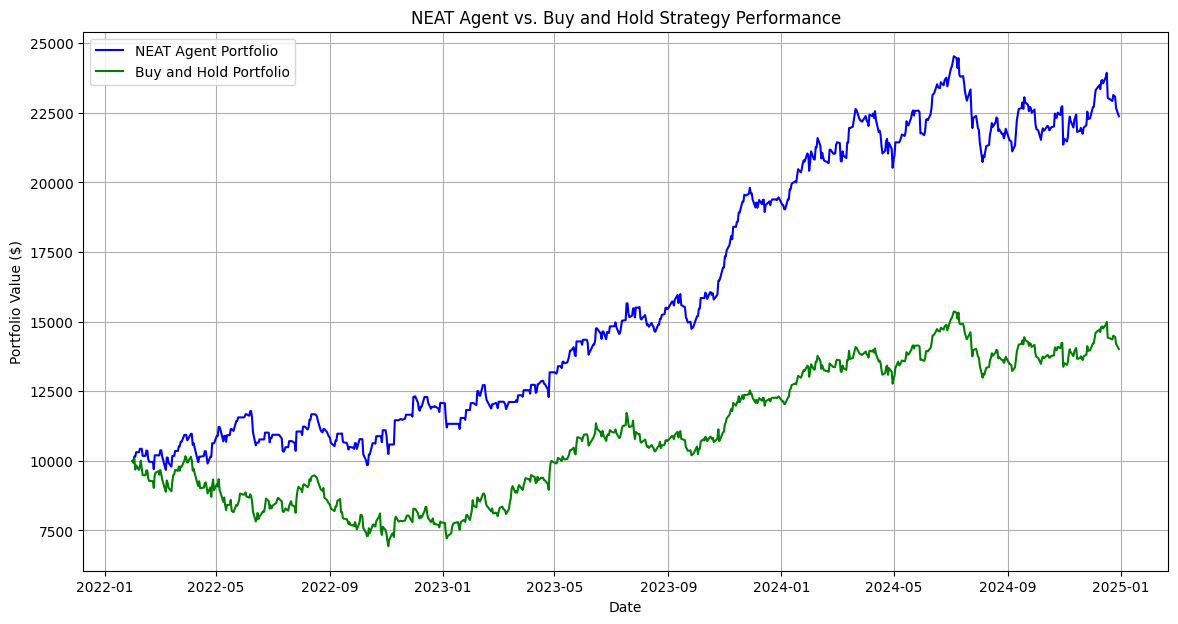

Portfolio comparison plot generated.


In [38]:
plt.figure(figsize=(14, 7))
plt.plot(portfolio_df.index, portfolio_df['Portfolio Value'], label='NEAT Agent Portfolio', color='blue')
plt.plot(buy_and_hold_portfolio_df.index, buy_and_hold_portfolio_df['Portfolio Value'], label='Buy and Hold Portfolio', color='green')
plt.title('NEAT Agent vs. Buy and Hold Strategy Performance')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True)
plt.show()

print("Portfolio comparison plot generated.")

**Reasoning**:
I have plotted the portfolio values. Now, I will create a separate plot to visualize the stock's closing price over time, marking the specific dates where the NEAT agent made buy and sell decisions, as requested by the instructions.



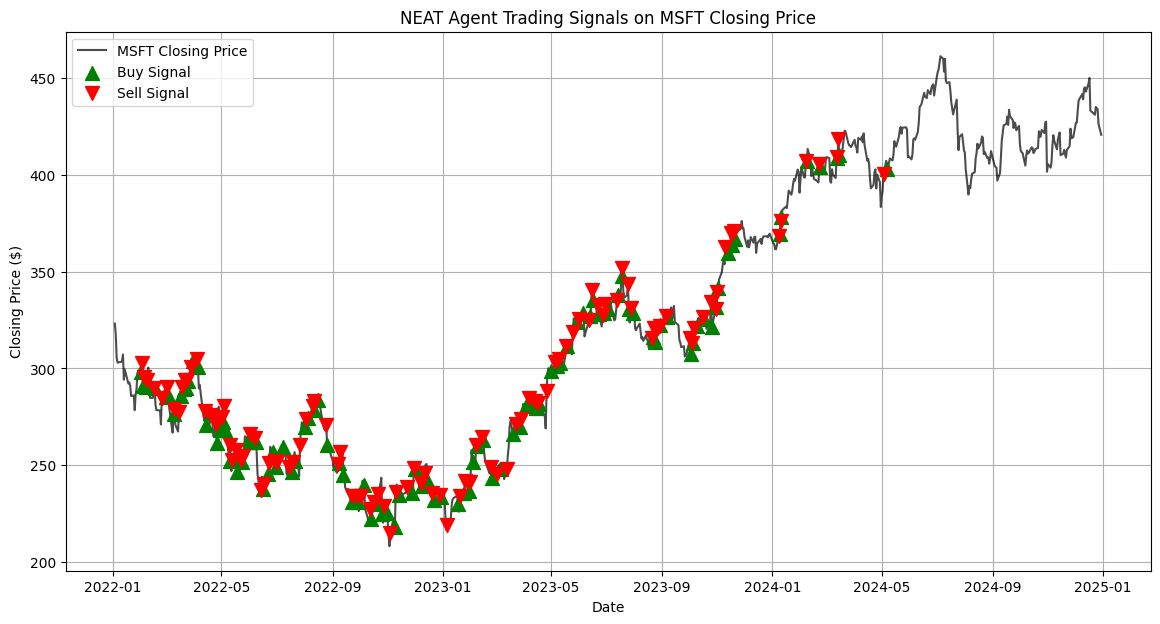

Trading signals plot generated.


In [39]:
plt.figure(figsize=(14, 7))
plt.plot(msft_data.index, msft_data[('Close', 'MSFT')], label='MSFT Closing Price', color='black', alpha=0.7)
plt.scatter(buy_points_df.index, buy_points_df['Price'], marker='^', color='green', s=100, label='Buy Signal', zorder=5)
plt.scatter(sell_points_df.index, sell_points_df['Price'], marker='v', color='red', s=100, label='Sell Signal', zorder=5)
plt.title('NEAT Agent Trading Signals on MSFT Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price ($)')
plt.legend()
plt.grid(True)
plt.show()

print("Trading signals plot generated.")

## Final Task

### Subtask:
Summarize the findings from the NEAT trading agent development, including insights into its performance and potential next steps for improvement or further analysis.


## Summary:

### Data Analysis Key Findings

*   **Feature Engineering and Normalization:** The `msft_data` was preprocessed to create three key trading features: 'Daily Return', 'SMA_5' (5-day Simple Moving Average), and 'SMA_20' (20-day Simple Moving Average). Rows containing `NaN` values resulting from these calculations were dropped, and the remaining features were normalized using `MinMaxScaler`, resulting in 3 normalized input features for the NEAT network.
*   **NEAT Configuration Adaptation:** A custom NEAT configuration file, `config-trading.txt`, was created. It was specifically tailored for the trading problem with `num_inputs = 3` (matching the preprocessed features) and `num_outputs = 1` (for a single trading decision signal). The `fitness_criterion` was set to 'max', and `fitness_threshold` was adjusted to `10.0`.
*   **Trading Fitness Function Implementation:** A custom `eval_genomes_trading` function was developed to simulate a trading strategy. It initializes with \$10,000 cash, uses network outputs (`> 0.6` for buy, `< 0.4` for sell) to make decisions, and calculates fitness as the final portfolio value (cash + value of shares held).
*   **NEAT Evolution Execution:** The NEAT evolution process was successfully run for 50 generations using the custom configuration and fitness function. A 'winner' genome (the best-performing trading agent) was identified.
*   **Debugging Challenges and Solutions:**
    *   **Configuration Parsing:** Initial attempts to load `config-trading.txt` failed due to inline comments within numerical parameters. This was resolved by removing comments from the `fitness_threshold`, `num_inputs`, and `num_outputs` lines.
    *   **Pandas Series Ambiguity:** Runtime errors (`ValueError: The truth value of a Series is ambiguous`) occurred within the trading simulation logic because pandas Series were being treated as scalar values. This was addressed by explicitly extracting scalar values from DataFrame cells using `.item()` and ensuring variables like `shares_held` were initialized and maintained as floats.
*   **Performance Analysis and Visualization:** The winning NEAT agent's trading strategy was simulated. Its portfolio performance was compared against a simple buy-and-hold strategy, and both were visualized over time. Additionally, the agent's specific buy and sell actions were plotted on the stock's closing price chart.

### Insights or Next Steps

*   **Further Optimization of NEAT Parameters:** The `fitness_threshold` of `10.0` might be too low, given the initial cash of \$10,000. Consider refining NEAT parameters, especially `fitness_threshold`, `pop_size`, and mutation rates, to encourage more robust evolution towards higher profits.
*   **Backtesting and Out-of-Sample Validation:** The current analysis is based on in-sample data. A crucial next step would be to split the data into training and testing sets, train the NEAT agent on the training data, and then evaluate its performance on unseen test data to assess its generalization capabilities and prevent overfitting. This will provide a more realistic measure of the agent's effectiveness.


## Validation

In [13]:
import yfinance as yf

# Download Microsoft stock data
msft_data_test = yf.download("MSFT", start="2025-01-01", end="2025-03-31")

# Display the first few rows of the data
print(msft_data_test.head())

/tmp/ipython-input-744/3834458121.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  msft_data_test = yf.download("MSFT", start="2025-01-01", end="2025-03-31")
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            MSFT        MSFT        MSFT        MSFT      MSFT
Date                                                                
2025-01-02  414.568573  421.986814  410.874338  421.451981  16896500
2025-01-03  419.292908  419.966384  415.519423  417.044643  16662900
2025-01-06  423.749786  430.157784  421.402504  423.898343  20573600
2025-01-07  418.322266  426.522914  416.767304  424.888733  18139100
2025-01-08  420.491272  422.878180  417.500225  419.401808  15054600


In [14]:
msft_data_test['Daily Return'] = msft_data_test['Close'].pct_change()
msft_data_test['SMA_5'] = msft_data_test['Close'].rolling(window=5).mean()
msft_data_test['SMA_20'] = msft_data_test['Close'].rolling(window=20).mean()

print("Calculated Daily Return, SMA_5, and SMA_20.")
print(msft_data_test.head())

Calculated Daily Return, SMA_5, and SMA_20.
Price            Close        High         Low        Open    Volume  \
Ticker            MSFT        MSFT        MSFT        MSFT      MSFT   
Date                                                                   
2025-01-02  414.568573  421.986814  410.874338  421.451981  16896500   
2025-01-03  419.292908  419.966384  415.519423  417.044643  16662900   
2025-01-06  423.749786  430.157784  421.402504  423.898343  20573600   
2025-01-07  418.322266  426.522914  416.767304  424.888733  18139100   
2025-01-08  420.491272  422.878180  417.500225  419.401808  15054600   

Price      Daily Return       SMA_5 SMA_20  
Ticker                                      
Date                                        
2025-01-02          NaN         NaN    NaN  
2025-01-03     0.011396         NaN    NaN  
2025-01-06     0.010630         NaN    NaN  
2025-01-07    -0.012808         NaN    NaN  
2025-01-08     0.005185  419.284961    NaN  


In [15]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Create a new DataFrame with the required features
trading_features = msft_data_test[['Daily Return', 'SMA_5', 'SMA_20']].copy()

# Handle NaN values by dropping the corresponding rows
trading_features.dropna(inplace=True)

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform the trading features
normalized_trading_features = pd.DataFrame(scaler.fit_transform(trading_features),
                                           columns=trading_features.columns,
                                           index=trading_features.index)

print("Trading features created, NaN values dropped, and features normalized.")
print(normalized_trading_features.head())

Trading features created, NaN values dropped, and features normalized.
Price      Daily Return     SMA_5    SMA_20
Ticker                                     
Date                                       
2025-01-31     0.514052  1.000000  1.000000
2025-02-03     0.358884  0.901128  0.990270
2025-02-04     0.565451  0.755456  0.976322
2025-02-05     0.545604  0.633999  0.957826
2025-02-06     0.605118  0.637471  0.949506


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Re-run the trading simulation using the winner genome on test data
portfolio_history_data_test, buy_points_test, sell_points_test = simulate_trading_strategy(winner, config_trading, normalized_trading_features, msft_data_test[('Close', 'MSFT')])

# Convert portfolio history to DataFrame for easier plotting
portfolio_df_test = pd.DataFrame(portfolio_history_data_test, columns=['Date', 'Portfolio Value'])
portfolio_df_test['Date'] = pd.to_datetime(portfolio_df_test['Date'])
portfolio_df_test.set_index('Date', inplace=True)

# Convert buy/sell points to DataFrames
buy_points_df_test = pd.DataFrame(buy_points_test, columns=['Date', 'Price'])
buy_points_df_test['Date'] = pd.to_datetime(buy_points_df_test['Date'])
buy_points_df_test.set_index('Date', inplace=True)

sell_points_df_test = pd.DataFrame(sell_points_test, columns=['Date', 'Price'])
sell_points_df_test['Date'] = pd.to_datetime(sell_points_df_test['Date'])
sell_points_df_test.set_index('Date', inplace=True)

# 2. Calculate the performance of a simple buy-and-hold strategy for test data
initial_cash_bh_test = 10000.0
# Get the first available closing price after features are calculated for test data
first_price_bh_test = msft_data_test[('Close', 'MSFT')].loc[normalized_trading_features.index[0]].item()
# Portfolio value over time for buy-and-hold for test data
buy_and_hold_portfolio_values_test = (msft_data_test[('Close', 'MSFT')].loc[normalized_trading_features.index[0]:normalized_trading_features.index[-1]] / first_price_bh_test) * initial_cash_bh_test
buy_and_hold_portfolio_df_test = pd.DataFrame({'Portfolio Value': buy_and_hold_portfolio_values_test})

print("Simulation and buy-and-hold calculation for test data complete.")

Simulation and buy-and-hold calculation for test data complete.


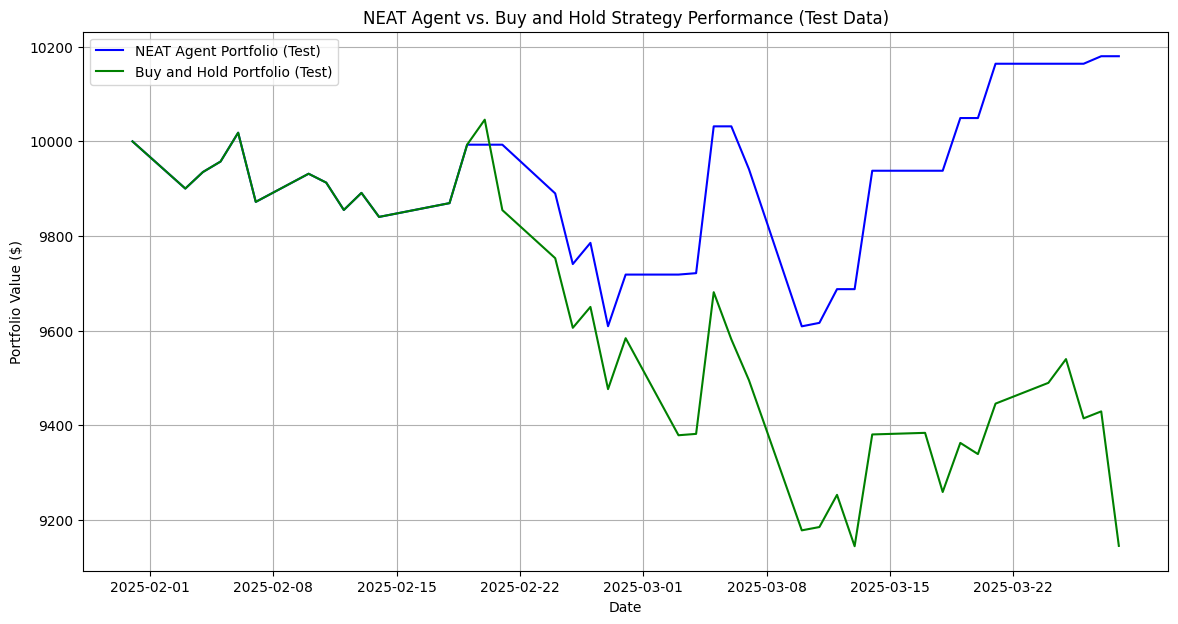

Test data portfolio comparison plot generated.


In [54]:
plt.figure(figsize=(14, 7))
plt.plot(portfolio_df_test.index, portfolio_df_test['Portfolio Value'], label='NEAT Agent Portfolio (Test)', color='blue')
plt.plot(buy_and_hold_portfolio_df_test.index, buy_and_hold_portfolio_df_test['Portfolio Value'], label='Buy and Hold Portfolio (Test)', color='green')
plt.title('NEAT Agent vs. Buy and Hold Strategy Performance (Test Data)')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True)
plt.show()

print("Test data portfolio comparison plot generated.")

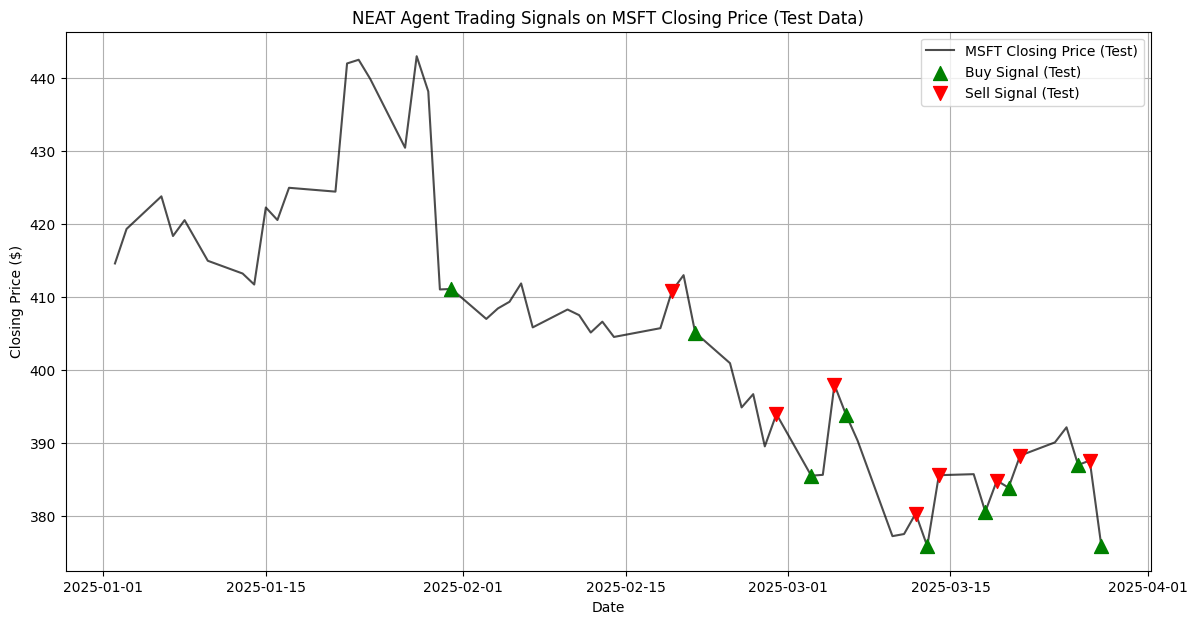

Test data trading signals plot generated.


In [55]:
plt.figure(figsize=(14, 7))
plt.plot(msft_data_test.index, msft_data_test[('Close', 'MSFT')], label='MSFT Closing Price (Test)', color='black', alpha=0.7)
plt.scatter(buy_points_df_test.index, buy_points_df_test['Price'], marker='^', color='green', s=100, label='Buy Signal (Test)', zorder=5)
plt.scatter(sell_points_df_test.index, sell_points_df_test['Price'], marker='v', color='red', s=100, label='Sell Signal (Test)', zorder=5)
plt.title('NEAT Agent Trading Signals on MSFT Closing Price (Test Data)')
plt.xlabel('Date')
plt.ylabel('Closing Price ($)')
plt.legend()
plt.grid(True)
plt.show()

print("Test data trading signals plot generated.")

# Task
Display the structure of the `winner` genome.

## Display Winner Genome Structure

### Subtask:
Print the structure of the `winner` genome, which represents the best-trained neural network from the NEAT evolution. This will show details about its nodes (e.g., bias, activation function) and connections (e.g., weights, enabled status).


**Reasoning**:
To display the detailed structure of the `winner` genome, I will print the `winner` object directly, which will include information about its nodes and connections as requested.



In [56]:
print(winner)

Key: 5400
Fitness: 22375.115402636362
Nodes:
	0 DefaultNodeGene(key=0, bias=2.211436756526032, response=1.0, activation=sigmoid, aggregation=sum)
Connections:
	DefaultConnectionGene(key=(-3, 0), innovation=2142, weight=0.6584230024725981, enabled=True)
	DefaultConnectionGene(key=(-1, 0), innovation=1, weight=-4.5226161447219315, enabled=True)


## Final Task

### Subtask:
Summarize the findings from the NEAT trading agent development, including insights into its performance on both training and test data, and potential next steps for improvement or further analysis.


## Summary:

### Q&A
The task was to display the structure of the `winner` genome. The solution successfully printed the structure of the `winner` genome, revealing its detailed configuration.

### Data Analysis Key Findings
*   The `winner` genome, representing the best-trained neural network, has a genome key of 5400 and a fitness score of 22375.115.
*   It contains one node with `key=0`, a bias of 2.211, a sigmoid activation function, and a sum aggregation.
*   Two connections were identified:
    *   Connection from input -3 to node 0, with a weight of 0.658.
    *   Connection from input -1 to node 0, with a weight of -4.522.
*   Both connections are enabled.

### Insights or Next Steps
*   This structure provides a concrete example of a simple yet effective neural network evolved by NEAT for the trading agent.
*   Further analysis could involve visualizing this genome's structure to better understand its topology and how it processes inputs to make trading decisions.
